# Figuring out how to plot wavelets

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import model
from model import generate_input_stim_xor

import vis_utils as vu
import importlib

2024-11-05 15:15:40.472754: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-05 15:15:40.473723: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-05 15:15:40.483363: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-05 15:15:40.491849: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 15:15:40.502496: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
model_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_162018'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [3]:
exc = mat_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = mat_data['inh']
inh_ind = np.where(inh == 1)[0]
print(inh_ind)

[  0   1   4   7   9  15  22  24  25  29  41  44  53  65  70  71  74  77
  85  94 106 112 120 122 123 135 137 138 155 180 181 184 186 187 188 191
 192]


In [4]:
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, model_fname, 'IPSCs_15trall.mat'))
ipsc_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'T', 'delay', 'ipscs_diffneg', 'ipscs_diffpos', 'ipscs_sameneg', 'ipscs_samepos', 'stim_dur', 'stim_on'])

In [5]:
ipscs_samepos = ipsc_data['ipscs_samepos']
ipscs_diffpos = ipsc_data['ipscs_diffpos']
ipscs_sameneg = ipsc_data['ipscs_sameneg']
ipscs_diffneg = ipsc_data['ipscs_diffneg']
T = ipsc_data['T'][0][0]
stim_on = ipsc_data['stim_on'][0][0]
stim_dur = ipsc_data['stim_dur'][0][0]
delay = ipsc_data['delay'][0][0]

print(ipscs_samepos.shape)
print(ipscs_diffpos.shape)
print(ipscs_sameneg.shape)
print(ipscs_diffneg.shape)
print(T)
print(stim_on)
print(stim_dur)
print(delay)

(200, 41100, 15)
(200, 41100, 15)
(200, 41100, 15)
(200, 41100, 15)
411
31
50
150


In [6]:
settings = {
        'T': T, # trial duration (in steps)
        'stim_on': stim_on, # input stim onset (in steps)
        'stim_dur': stim_dur, # input stim duration (in steps)
        'delay': delay, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

print(f'T: {settings["T"]}')
print(f'stim_on: {settings["stim_on"]}')
print(f'stim_dur: {settings["stim_dur"]}')
print(f'delay: {settings["delay"]}')

T: 411
stim_on: 31
stim_dur: 50
delay: 150


In [7]:
fs_rate = 200
fs_spk = 20000

# get trial times in real time (seconds)
stim_on_time = stim_on/fs_rate
stim_dur_time = stim_dur/fs_rate
delay_time = delay/fs_rate
stim1_on = stim_on_time
stim1_off = stim_on_time + stim_dur_time
stim2_on = stim_on_time + stim_dur_time + delay_time
stim2_off = stim_on_time + 2*stim_dur_time + delay_time

In [8]:
# import scipy.signal

def downsample(signal, fs_high, fs_low):
    '''
    Downsample signal from high to low sampling rate
    '''
    t_high = np.arange(0, len(signal)/fs_high, 1/fs_high)
    num_samples = int(len(t_high) * fs_low / fs_high)
    signal_low = scipy.signal.resample(signal, num_samples)

    return signal_low

In [9]:
import pywt

(2055,)


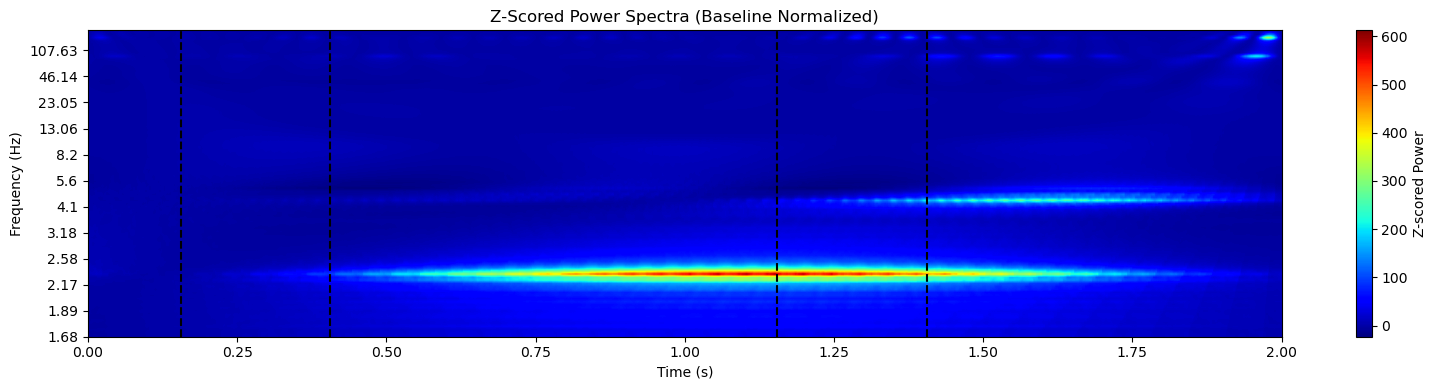

In [27]:
# Start with a raw LFP signal — downsample to 1000Hz
fs_spk = 20000  # Sampling frequency (Hz)
fs = 1000  # Desired sampling frequency (Hz)

# LFP signal, downsample to 1000Hz
lfp_signal = downsample(ipscs_samepos[0,:,2], fs_spk, fs)
t = np.linspace(0, len(lfp_signal)/fs, num=len(lfp_signal), endpoint=False)  
print(lfp_signal.shape)

# Step 1: Define the start and end points for the x range for exponential spacing
x_start = 6 / 8  # 6/8
x_end = 54 / 8   # 54/8

# Step 2: Create 100 exponentially spaced values of x between x_start and x_end
x_values = np.logspace(np.log10(x_start), np.log10(x_end), num=100)

# Step 3: Compute the corresponding frequencies f0 = 2 ^ x_values
f0s = 2 **x_values

# Step 4: Perform CWT using Morlet wavelet (complex-valued) with the exponentially spaced frequencies
c = 7  # Wavelet parameter (7 oscillations per wavelet)
coefficients, frequencies = pywt.cwt(lfp_signal, np.array([c * fs / f for f in f0s]), 'morl')

# Step 5: Compute Instantaneous Amplitude (Magnitude of Complex Signal) and Phase (Angle)
instantaneous_amplitude = np.abs(coefficients)  # Magnitude (instantaneous amplitude)
instantaneous_phase = np.angle(coefficients)  # Phase (angle)

# Step 6: Compute Power Spectra (Amplitude Squared)
power_spectra = instantaneous_amplitude ** 2

# Step 7: Baseline Z-Score Transformation
# Assuming baseline period is 500 ms before the first stimulus, let's define a baseline window
baseline_end = int(stim_on/200 * fs)  # stimulus onset time
baseline_start = int(baseline_end/2)    # Half the time before stimulus onset

# Compute mean and std of power during baseline period
baseline_power = np.mean(power_spectra[:, baseline_start:baseline_end], axis=1)
baseline_std = np.std(power_spectra[:, baseline_start:baseline_end], axis=1)

# Z-score transformation: (power - mean) / std
z_scored_power = (power_spectra - baseline_power[:, None]) / baseline_std[:, None]

# Step 8: Plot the results
plt.figure(figsize=(16,4))

plt.imshow(z_scored_power, aspect='auto', extent=[0, 2, np.min(f0s), np.max(f0s)],
           origin='lower', cmap='jet', interpolation='bilinear')
plt.colorbar(label='Z-scored Power')
plt.title("Z-Scored Power Spectra (Baseline Normalized)")
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.yticks(range(len(f0s))[::9]+f0s[0], f0s[::9].round(2))
plt.axvline(stim1_on, color='k', linestyle='--', label='Stim 1 Onset')
plt.axvline(stim1_off, color='k', linestyle='--', label='Stim 1 Offset')    
plt.axvline(stim2_on, color='k', linestyle='--', label='Stim 2 Onset')
plt.axvline(stim2_off, color='k', linestyle='--', label='Stim 2 Offset')

plt.tight_layout()
plt.show()


In [36]:
def calc_wavelet(lfp_signal, stim_on, c=7, wavelet='morl', fs = 1000, plot=0, settings=None, neuron_type='exc'):
    # takes in signals at fs Hz
    # stim_on is in real time
    # c is the wavelet parameter (7 oscillations per wavelet)
    # wavelet is the type of wavelet to use (morlet)

    t = np.linspace(0, len(lfp_signal)/fs, num=len(lfp_signal), endpoint=False)

    x_start = 6 / 8  # 6/8
    x_end = 54 / 8   # 54/8
    x_values = np.logspace(np.log10(x_start), np.log10(x_end), num=100) # 100 exponentially spaced values of x between x_start and x_end

    f0s = 2 **x_values  # Compute the corresponding frequencies f0 = 2 ^ x_values
    scales = np.array([c * fs / f for f in f0s])  # Wavelet scales
    coefficients, frequencies = pywt.cwt(lfp_signal, scales, wavelet)  # Perform CWT using Morlet wavelet (complex-valued) with the exponentially spaced frequencies
    power_spectra = np.abs(coefficients) ** 2  # Compute Power Spectra (Amplitude Squared)

    # z-score with baseline
    baseline_end = int(stim_on * fs)  # stimulus onset time
    baseline_start = int(baseline_end/2)    # Half the time before stimulus onset
    baseline_power = np.mean(power_spectra[:, baseline_start:baseline_end], axis=1)
    baseline_std = np.std(power_spectra[:, baseline_start:baseline_end], axis=1)
    z_scored_power = (power_spectra - baseline_power[:, None]) / baseline_std[:, None]

    if plot:
        plt.figure(figsize=(16,4))
        plt.imshow(z_scored_power, aspect='auto', extent=[0, 2, np.min(f0s), np.max(f0s)],
                origin='lower', cmap='jet', interpolation='bilinear')
        plt.colorbar(label='Z-scored Power')
        plt.title(f'Z-Scored Power Spectra (Baseline Normalized), {neuron_type} Neurons')
        plt.xlabel('Time (s)')
        plt.ylabel('Frequency (Hz)')
        plt.yticks(range(len(f0s))[::9]+f0s[0], f0s[::9].round(2))
        plt.axvline(settings['stim1_on'], color='k', linestyle='--', label='Stim 1 Onset')
        plt.axvline(settings['stim1_off'], color='k', linestyle='--', label='Stim 1 Offset')    
        plt.axvline(settings['stim2_on'], color='k', linestyle='--', label='Stim 2 Onset')
        plt.axvline(settings['stim2_off'], color='k', linestyle='--', label='Stim 2 Offset')

        plt.tight_layout()
        plt.show()

In [32]:
# Start with a raw LFP signal — downsample to 1000Hz
fs_spk = 20000  # Sampling frequency (Hz)
fs = 1000  # Desired sampling frequency (Hz)

settings = {
        'stim1_on': stim1_on, # input stim onset (in steps)
        'stim1_off': stim1_off, # input stim duration (in steps)
        'stim2_on': stim2_on, # delay b/w the two stimuli (in steps)
        'stim2_off': stim2_off, # delay b/w the two stimuli (in steps)
        }

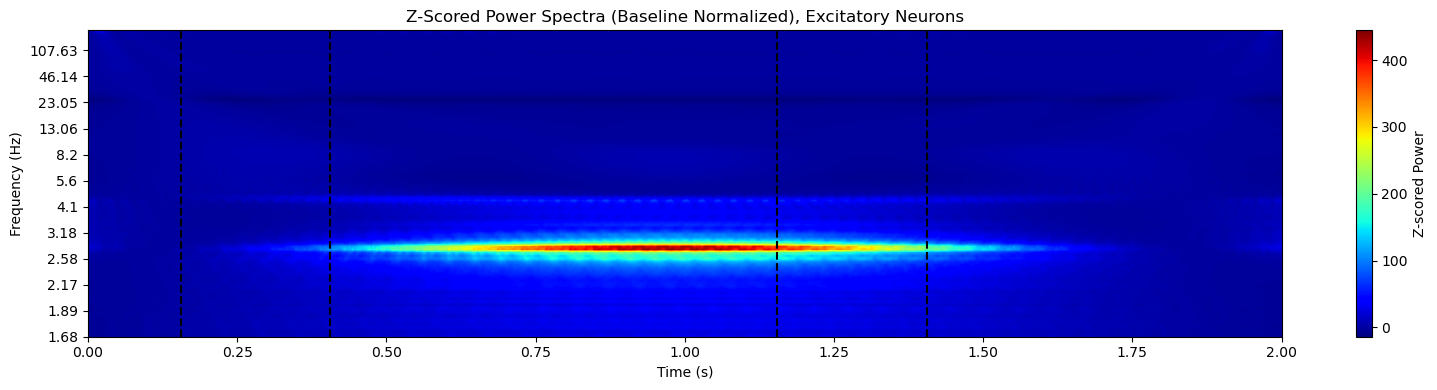

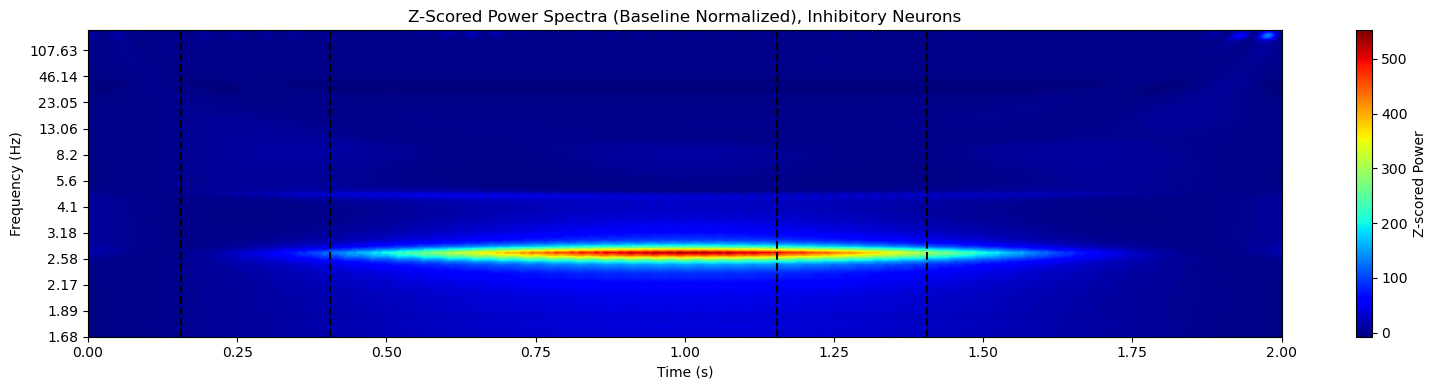

In [37]:
# LFP signal, downsample to 1000Hz
lfp_signal_exc = downsample(np.nanmean(ipscs_samepos[exc_ind,:,0], axis=0), fs_spk, fs)
lfp_signal_inh = downsample(np.nanmean(ipscs_samepos[inh_ind,:,0], axis=0), fs_spk, fs)

calc_wavelet(lfp_signal_exc, stim_on = settings['stim1_on'], c=7, wavelet='morl', fs = 1000, plot=1, settings=settings, neuron_type = 'Excitatory')
calc_wavelet(lfp_signal_inh, stim_on = settings['stim1_on'], c=7, wavelet='morl', fs = 1000, plot=1, settings=settings, neuron_type = 'Inhibitory')